# Census Tracts to NYC Taxi Zones: Simplified Spatial Joining

This notebook converts ACS household information from census tracts to the **262 taxi zones within the five NYC boroughs**. It retains the important spatial allocation, uncertainty, coverage, validation, visualisation, and export steps without repeating the same diagnostics.

The resulting file contains one static Census profile per `LocationID`, ready to join later to time-aggregated taxi-demand data. Area weighting assumes that households are distributed uniformly across each tract's intersected area.

## 1. Setup and paths

Change only `PROJECT_ROOT` if the project folder is moved.

### 1.1 Import Libraries and Configure Display

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
plt.rcParams["figure.dpi"] = 110

print("Libraries and display settings loaded successfully.")


Libraries and display settings loaded successfully.


### 1.2 Define and Display Project Paths

In [2]:
# Project folders and files
PROJECT_ROOT = Path(
    r"C:\Asia Pacific University\All Module Notes\Semister-5\Investigations"
    r"\FYP Semester 1\Progress\fyp"
)
PROCESSED_DIR = PROJECT_ROOT / "processed_outputs"
CENSUS_PATH = PROCESSED_DIR / "census_tract" / "nyc_zero_vehicle_households_by_tract.gpkg"
TAXI_PATH = PROCESSED_DIR / "taxi_zone" / "nyc_taxi_zones_cleaned.gpkg"
OUTPUT_DIR = PROCESSED_DIR / "spatial_joining"

CSV_PATH = OUTPUT_DIR / "nyc_taxi_zones_with_zero_vehicle_context.csv"
GPKG_PATH = OUTPUT_DIR / "nyc_taxi_zones_with_zero_vehicle_context.gpkg"

display(pd.Series({
    "census_input": str(CENSUS_PATH),
    "taxi_input": str(TAXI_PATH),
    "output_folder": str(OUTPUT_DIR),
}))


census_input     C:\Asia Pacific University\All Module Notes\Se...
taxi_input       C:\Asia Pacific University\All Module Notes\Se...
output_folder    C:\Asia Pacific University\All Module Notes\Se...
dtype: object

**Interpretation.** Confirm that both input paths point to the processed Census and taxi-zone GeoPackages. The output folder is where the integration-ready files will be written.

## 2. Load and validate the inputs

Only validations that protect the spatial join and final data contract are retained. LocationID 1 (EWR) is excluded because it is outside the five NYC boroughs.

### 2.1 Load and Inspect the Cleaned Layers

In [3]:
# Load the cleaned layers
census_gdf = gpd.read_file(CENSUS_PATH, layer="nyc_tract_zero_vehicle")
taxi_gdf = gpd.read_file(TAXI_PATH, layer="nyc_taxi_zones")

display(pd.DataFrame({
    "dataset": ["Census tracts", "Taxi zones"],
    "rows": [len(census_gdf), len(taxi_gdf)],
    "columns": [census_gdf.shape[1], taxi_gdf.shape[1]],
    "crs": [census_gdf.crs.to_string(), taxi_gdf.crs.to_string()],
}))
display(census_gdf.head(3))
display(taxi_gdf.head(3))


,dataset,rows,columns,crs
0,Census tracts,2327,26,EPSG:4269
1,Taxi zones,262,5,EPSG:2263


,tract_geoid,ALAND,AWATER,acs_geographic_name,state_fips,county_fips,tract_code,borough,total_households_estimate,total_households_moe,zero_vehicle_households_estimate,zero_vehicle_households_moe,total_households_lower,total_households_upper,zero_vehicle_households_lower,zero_vehicle_households_upper,zero_vehicle_household_rate,zero_vehicle_rate_se,zero_vehicle_rate_moe,zero_vehicle_rate_ci_lower,zero_vehicle_rate_ci_upper,zero_vehicle_rate_ci_width,zero_vehicle_rate_cv,zero_vehicle_rate_moe_method,rate_cv_reference_group,geometry
0,36081003400,213987,0,Census Tract 34; Queens County; New York,36,081,003400,Queens,728,104,304,116,624,832,188,420,0.417582,0.089819,0.147752,0.269830,0.565335,0.295505,0.215093,proportion approximation,CV <= 30% diagnostic reference,"MULTIPOLYGON (((-73.8663 40.68319, -73.86549 4..."
1,36081003900,146970,0,Census Tract 39; Queens County; New York,36,081,003900,Queens,519,192,170,58,327,711,112,228,0.327553,0.100207,0.164840,0.162713,0.492393,0.329681,0.305926,alternative ratio approximation,CV > 30% diagnostic reference,"MULTIPOLYGON (((-73.9433 40.76066, -73.94247 4..."
2,36081003600,180006,0,Census Tract 36; Queens County; New York,36,081,003600,Queens,1070,237,369,195,833,1307,174,564,0.344860,0.100585,0.165463,0.179397,0.510322,0.330925,0.291670,proportion approximation,CV <= 30% diagnostic reference,"MULTIPOLYGON (((-73.8641 40.68237, -73.8637 40..."


,LocationID,borough,zone,service_zone,geometry
0,2,Queens,Jamaica Bay,Boro Zone,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
1,3,Bronx,Allerton/Pelham Gardens,Boro Zone,"MULTIPOLYGON (((1026308.77 256767.698, 1026495..."
2,4,Manhattan,Alphabet City,Yellow Zone,"MULTIPOLYGON (((992073.467 203714.076, 992068...."


**Interpretation.** The expected inputs contain 2,327 NYC Census tracts and 262 five-borough taxi zones. Their different starting CRSs are handled in the next spatial-preparation step.

### 2.2 Validate Required Fields, Identifiers, and Geometry

In [4]:
# Essential schema, identifier, and geometry checks
census_fields = {
    "tract_geoid", "total_households_estimate", "total_households_moe",
    "zero_vehicle_households_estimate", "zero_vehicle_households_moe",
    "ALAND", "AWATER", "geometry",
}
taxi_fields = {"LocationID", "borough", "zone", "service_zone", "geometry"}

assert census_fields.issubset(census_gdf.columns)
assert taxi_fields.issubset(taxi_gdf.columns)
assert len(census_gdf) == 2327 and census_gdf["tract_geoid"].is_unique
assert len(taxi_gdf) == 262 and taxi_gdf["LocationID"].is_unique
assert set(taxi_gdf["LocationID"].astype(int)) == set(range(2, 264))
assert census_gdf.geometry.notna().all() and census_gdf.geometry.is_valid.all()
assert taxi_gdf.geometry.notna().all() and taxi_gdf.geometry.is_valid.all()

display(pd.Series({
    "census_fields_present": census_fields.issubset(census_gdf.columns),
    "taxi_fields_present": taxi_fields.issubset(taxi_gdf.columns),
    "census_records": len(census_gdf),
    "taxi_zone_records": len(taxi_gdf),
    "unique_tract_geoids": census_gdf["tract_geoid"].is_unique,
    "unique_location_ids": taxi_gdf["LocationID"].is_unique,
    "location_ids_2_to_263": set(taxi_gdf["LocationID"].astype(int)) == set(range(2, 264)),
    "valid_census_geometry": census_gdf.geometry.is_valid.all(),
    "valid_taxi_geometry": taxi_gdf.geometry.is_valid.all(),
}, name="validation_result"))


census_fields_present    True
taxi_fields_present      True
census_records           2327
taxi_zone_records         262
unique_tract_geoids      True
unique_location_ids      True
location_ids_2_to_263    True
valid_census_geometry    True
valid_taxi_geometry      True
Name: validation_result, dtype: object

**Interpretation.** All required fields, identifiers, record-count contracts, and geometry checks passed. Assertions are retained as safeguards, while this visible message confirms successful execution.

## 3. Classify Tract Land/Water Composition and Taxi-Zone Coverage

The official TIGER/Line `ALAND` and `AWATER` attributes are used before any exclusion. Tracts are classified as land-only, mixed land and water, water-only, or unclassified. Taxi-zone coverage is measured from actual polygon-overlap area rather than assumed from tract names or codes.

### 3.1 Align the CRS and Calculate Polygon Areas

In [5]:
# Align both datasets and calculate source polygon areas
census_projected = census_gdf.to_crs(epsg=2263).copy()
taxi_projected = taxi_gdf.to_crs(epsg=2263).copy()
census_projected["tract_area_sqft"] = census_projected.geometry.area
taxi_projected["taxi_zone_area_sqft"] = taxi_projected.geometry.area

assert census_projected["tract_area_sqft"].gt(0).all()
assert taxi_projected["taxi_zone_area_sqft"].gt(0).all()

display(pd.DataFrame({
    "dataset": ["Census tracts", "Taxi zones"],
    "crs": [census_projected.crs.to_string(), taxi_projected.crs.to_string()],
    "minimum_area_sqft": [
        census_projected["tract_area_sqft"].min(),
        taxi_projected["taxi_zone_area_sqft"].min(),
    ],
}))

,dataset,crs,minimum_area_sqft
0,Census tracts,EPSG:2263,"416,125.242888"
1,Taxi zones,EPSG:2263,"639,620.233131"


**Interpretation.** Both datasets now use EPSG:2263, which supports area calculations in square feet. Positive minimum areas confirm that neither layer contains zero-area polygons.

### 3.2 Classify Tracts and Measure Taxi-Zone Coverage

In [6]:
# Classify each tract using the official TIGER/Line land and water area fields
land_area = pd.to_numeric(census_projected["ALAND"], errors="coerce")
water_area = pd.to_numeric(census_projected["AWATER"], errors="coerce")
assert land_area.notna().all() and water_area.notna().all()
assert land_area.ge(0).all() and water_area.ge(0).all()

census_projected["tract_surface_class"] = np.select(
    [
        land_area.eq(0) & water_area.gt(0),
        land_area.gt(0) & water_area.eq(0),
        land_area.gt(0) & water_area.gt(0),
    ],
    ["water-only", "land-only", "mixed land and water"],
    default="unclassified",
)

# Measure polygon-area overlap with the combined taxi-zone footprint
taxi_zone_footprint = taxi_projected.geometry.union_all()
census_projected["taxi_overlap_area_sqft"] = (
    census_projected.geometry.intersection(taxi_zone_footprint).area
)
census_projected["taxi_zone_coverage_status"] = np.where(
    census_projected["taxi_overlap_area_sqft"].gt(0),
    "overlaps taxi zones",
    "no taxi-zone area overlap",
)

surface_coverage_summary = pd.crosstab(
    census_projected["tract_surface_class"],
    census_projected["taxi_zone_coverage_status"],
    margins=True,
).rename_axis(index="tract_surface_class", columns="taxi_zone_coverage")

display(surface_coverage_summary)


taxi_zone_coverage,no taxi-zone area overlap,overlaps taxi zones,All
tract_surface_class,,,
land-only,0,2021,2021
mixed land and water,0,303,303
water-only,3,0,3
All,3,2324,2327


**Interpretation.** The table separates land-only, mixed land-and-water, and water-only tracts and shows whether each group has taxi-zone polygon-area overlap. Classification is based directly on `ALAND` and `AWATER`.

### 3.3 Visualise Land/Water Classes and Taxi-Zone Coverage

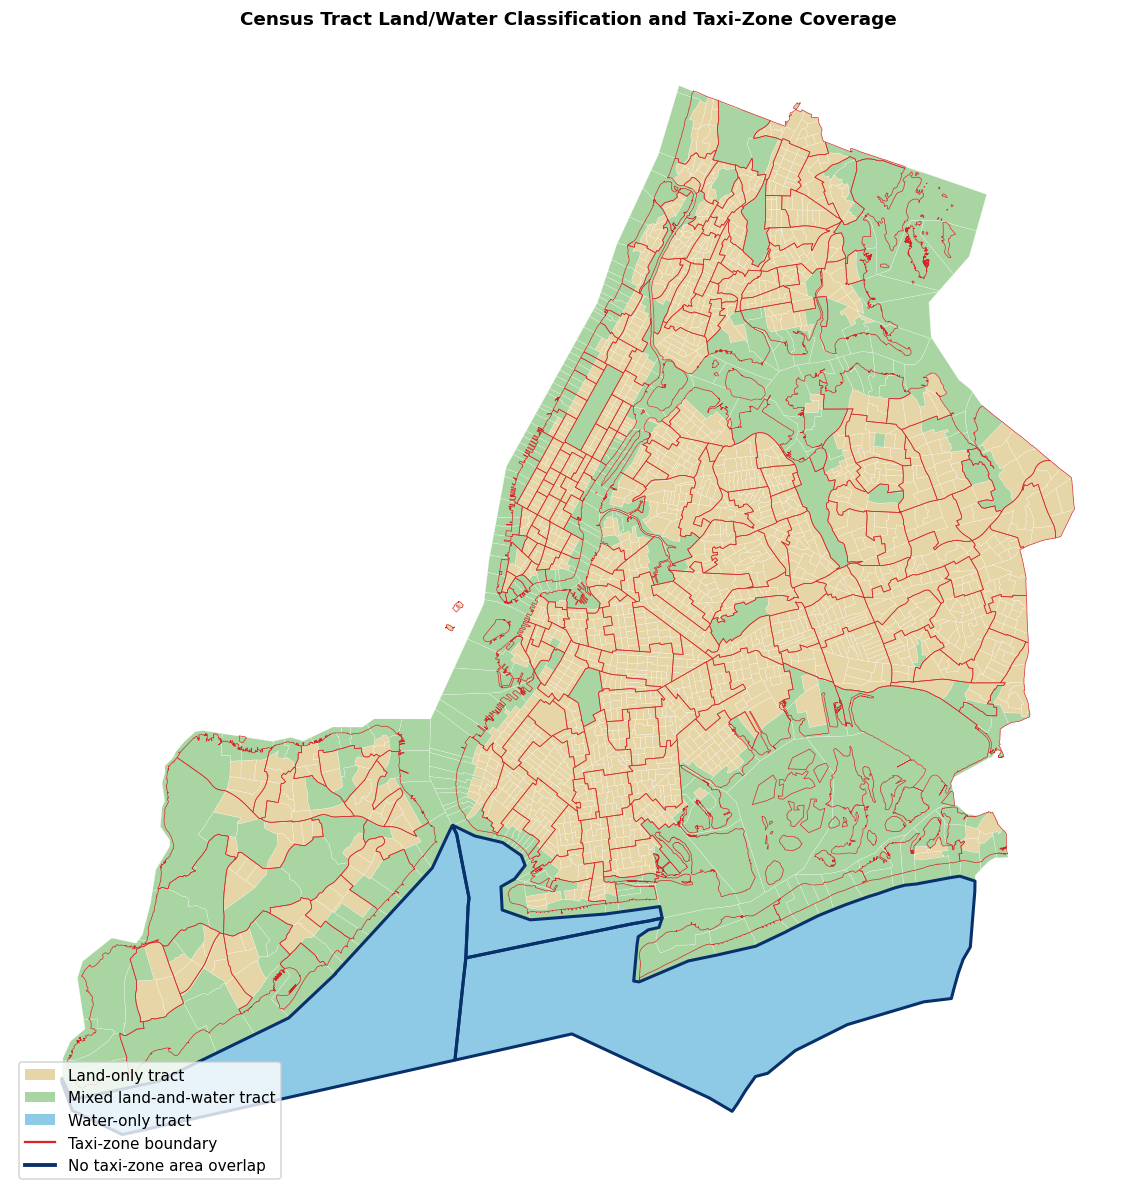

In [7]:
# Map land/water tract classes with taxi-zone and uncovered-tract boundaries
surface_colours = {
    "land-only": "#e6d5a7",
    "mixed land and water": "#a8d5a2",
    "water-only": "#8ecae6",
    "unclassified": "#d9d9d9",
}

fig, ax = plt.subplots(figsize=(11, 11))
for surface_class, colour in surface_colours.items():
    subset = census_projected.loc[
        census_projected["tract_surface_class"].eq(surface_class)
    ]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, edgecolor="white", linewidth=0.15)

taxi_projected.boundary.plot(ax=ax, color="#d62728", linewidth=0.45)
census_projected.loc[
    census_projected["taxi_zone_coverage_status"].eq("no taxi-zone area overlap")
].boundary.plot(ax=ax, color="#08306b", linewidth=2.0)

legend_items = [
    Patch(facecolor=surface_colours["land-only"], label="Land-only tract"),
    Patch(facecolor=surface_colours["mixed land and water"], label="Mixed land-and-water tract"),
    Patch(facecolor=surface_colours["water-only"], label="Water-only tract"),
    Line2D([0], [0], color="#d62728", lw=1.5, label="Taxi-zone boundary"),
    Line2D([0], [0], color="#08306b", lw=2.5, label="No taxi-zone area overlap"),
]
ax.legend(handles=legend_items, loc="lower left", frameon=True)
ax.set_title("Census Tract Land/Water Classification and Taxi-Zone Coverage", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()


**Interpretation.** Beige polygons are land-only tracts, green polygons contain both land and water, and blue polygons are water-only. Red lines show taxi-zone boundaries. Dark-blue outlines identify tracts with no taxi-zone polygon-area overlap.

### 3.4 Validate and Justify Exclusion from the Analytical Overlay

In [8]:
# Inspect and validate tracts that have no taxi-zone polygon-area overlap
uncovered_tracts = census_projected.loc[
    census_projected["taxi_zone_coverage_status"].eq("no taxi-zone area overlap")
].copy()

zero_household = (
    uncovered_tracts["total_households_estimate"].eq(0)
    & uncovered_tracts["zero_vehicle_households_estimate"].eq(0)
)
validated_exclusion = (
    uncovered_tracts["tract_surface_class"].eq("water-only")
    & uncovered_tracts["ALAND"].eq(0)
    & uncovered_tracts["AWATER"].gt(0)
    & zero_household
)

assert validated_exclusion.all()
excluded_tracts = uncovered_tracts.loc[validated_exclusion].copy()
assert len(excluded_tracts) == len(uncovered_tracts)

excluded_tracts["exclusion_reason"] = (
    "Water-only tract with no taxi-zone polygon-area overlap and zero households"
)

# This filtered layer becomes the tract input used by the remaining pipeline
census_for_overlay = census_projected.loc[
    ~census_projected.index.isin(excluded_tracts.index)
].copy()

display(excluded_tracts[[
    "tract_geoid", "borough", "ALAND", "AWATER",
    "total_households_estimate", "zero_vehicle_households_estimate",
    "tract_surface_class", "taxi_zone_coverage_status", "exclusion_reason",
]])
display(pd.Series({
    "source_census_tracts": len(census_projected),
    "validated_water_tracts_excluded": len(excluded_tracts),
    "tracts_retained_for_allocation": len(census_for_overlay),
    "households_removed": excluded_tracts["total_households_estimate"].sum(),
    "zero_vehicle_households_removed": excluded_tracts["zero_vehicle_households_estimate"].sum(),
}))


,tract_geoid,borough,ALAND,AWATER,total_households_estimate,zero_vehicle_households_estimate,tract_surface_class,taxi_zone_coverage_status,exclusion_reason
777,36047990100,Brooklyn,0,17793788,0,0,water-only,no taxi-zone area overlap,Water-only tract with no taxi-zone polygon-are...
1727,36081990100,Queens,0,130800077,0,0,water-only,no taxi-zone area overlap,Water-only tract with no taxi-zone polygon-are...
2110,36085990100,Staten Island,0,81772671,0,0,water-only,no taxi-zone area overlap,Water-only tract with no taxi-zone polygon-are...


source_census_tracts               2327
validated_water_tracts_excluded       3
tracts_retained_for_allocation     2324
households_removed                    0
zero_vehicle_households_removed       0
dtype: int64

**Interpretation and exclusion justification.** A tract is excluded before allocation only when it has no taxi-zone polygon-area overlap, zero land area, positive water area, and zero total and zero-vehicle households. The displayed summary records how many tracts were excluded and confirms that no households were removed. Therefore, the final taxi-zone dataset already reflects this validated filtering step.


## 4. Spatial Intersection and Tract-Normalised Allocation Weights

Only the validated analytical tract set proceeds to the overlay. The resulting tract–taxi-zone intersections are then converted into allocation weights that sum to one within each retained tract.

### 4.1 Intersect Retained Census Tracts with Taxi Zones

In [9]:
# Retain only fields required by the polygon overlay
census_overlay = census_for_overlay[[
    "tract_geoid", "total_households_estimate", "total_households_moe",
    "zero_vehicle_households_estimate", "zero_vehicle_households_moe",
    "geometry",
]]
taxi_overlay = taxi_projected[[
    "LocationID", "taxi_zone_area_sqft", "geometry",
]]

# Split retained tracts wherever they cross taxi-zone boundaries
intersection_gdf = gpd.overlay(
    census_overlay,
    taxi_overlay,
    how="intersection",
    keep_geom_type=True,
    make_valid=False,
)
intersection_gdf["intersection_area_sqft"] = intersection_gdf.geometry.area

assert intersection_gdf.geometry.is_valid.all()
assert intersection_gdf["intersection_area_sqft"].gt(0).all()

display(pd.Series({
    "intersection_pieces": len(intersection_gdf),
    "intersecting_tracts": intersection_gdf["tract_geoid"].nunique(),
    "intersecting_taxi_zones": intersection_gdf["LocationID"].nunique(),
}))


intersection_pieces        5219
intersecting_tracts        2324
intersecting_taxi_zones     262
dtype: int64

**Interpretation.** The overlay connects Census tracts to all 262 taxi zones. Multiple pieces are expected because tracts can cross taxi-zone boundaries.

### 4.2 Create and Validate Tract-Normalised Allocation Weights

In [10]:
# Consolidate to unique tract–taxi-zone pairs and normalise each tract's weights
pairs = (
    intersection_gdf.groupby(["tract_geoid", "LocationID"], as_index=False)
    .agg(
        intersection_area_sqft=("intersection_area_sqft", "sum"),
        taxi_zone_area_sqft=("taxi_zone_area_sqft", "first"),
        total_households_estimate=("total_households_estimate", "first"),
        total_households_moe=("total_households_moe", "first"),
        zero_vehicle_households_estimate=("zero_vehicle_households_estimate", "first"),
        zero_vehicle_households_moe=("zero_vehicle_households_moe", "first"),
    )
)
pairs["tract_intersected_area_sqft"] = (
    pairs.groupby("tract_geoid")["intersection_area_sqft"].transform("sum")
)
pairs["allocation_weight"] = (
    pairs["intersection_area_sqft"] / pairs["tract_intersected_area_sqft"]
)

weight_sums = pairs.groupby("tract_geoid")["allocation_weight"].sum()
assert pairs["allocation_weight"].notna().all()
assert pairs["allocation_weight"].between(0, 1).all()
assert np.allclose(weight_sums, 1.0, atol=1e-12)

display(pd.Series({
    "tract_taxi_pairs": len(pairs),
    "minimum_weight_sum": weight_sums.min(),
    "maximum_weight_sum": weight_sums.max(),
    "all_tract_weight_sums_equal_one": np.allclose(weight_sums, 1.0, atol=1e-12),
}))


tract_taxi_pairs                      5219
minimum_weight_sum                1.000000
maximum_weight_sum                1.000000
all_tract_weight_sums_equal_one       True
dtype: object

**Interpretation.** Each retained tract's weights sum to approximately one, ensuring that its ACS estimates are fully distributed across the taxi zones it intersects without losing household totals.

## 5. Allocate and aggregate the Census values

Estimates and MOEs use the same area weight. Allocated estimates are summed by taxi zone, while independent MOE components are combined using root-sum-of-squares.

### 5.1 Allocate Census Estimates and Margins of Error

In [11]:
# Allocate tract estimates and margins of error
allocation_map = {
    "total_households_estimate": "allocated_total_households",
    "zero_vehicle_households_estimate": "allocated_zero_vehicle_households",
    "total_households_moe": "allocated_total_households_moe",
    "zero_vehicle_households_moe": "allocated_zero_vehicle_households_moe",
}
for source, target in allocation_map.items():
    pairs[target] = pairs[source] * pairs["allocation_weight"]

assert np.isclose(
    pairs["allocated_total_households"].sum(),
    census_gdf["total_households_estimate"].sum(),
)
assert np.isclose(
    pairs["allocated_zero_vehicle_households"].sum(),
    census_gdf["zero_vehicle_households_estimate"].sum(),
)

display(pairs[list(allocation_map.values())].describe())


,allocated_total_households,allocated_zero_vehicle_households,allocated_total_households_moe,allocated_zero_vehicle_households_moe
count,"5,219.000000","5,219.000000","5,219.000000","5,219.000000"
mean,638.836559,353.459667,91.139490,81.472121
std,940.515815,655.831043,132.606064,126.735609
min,0.000000,0.000000,0.000000,0.000000
25%,0.035907,0.016112,0.007585,0.006584
50%,2.906959,1.223297,0.710970,0.597175
75%,"1,137.377406",439.250178,164.998224,137.998476
max,"7,967.521544","5,921.398964","1,276.852688","1,203.861109"


**Interpretation.** The allocated values are non-negative tract contributions. Their totals are checked against the original ACS totals before taxi-zone aggregation.

### 5.2 Aggregate the Allocated Values to Taxi Zones

In [12]:
# Aggregate to one record per taxi zone
zone_aggregated = (
    pairs.groupby("LocationID", as_index=False)
    .agg(
        estimated_total_households=("allocated_total_households", "sum"),
        estimated_zero_vehicle_households=("allocated_zero_vehicle_households", "sum"),
        total_moe_sq=("allocated_total_households_moe", lambda x: np.square(x).sum()),
        zero_moe_sq=("allocated_zero_vehicle_households_moe", lambda x: np.square(x).sum()),
        contributing_tract_count=("tract_geoid", "nunique"),
        intersected_area_sqft=("intersection_area_sqft", "sum"),
        taxi_zone_area_sqft=("taxi_zone_area_sqft", "first"),
    )
)
zone_aggregated["estimated_total_households_moe"] = np.sqrt(zone_aggregated.pop("total_moe_sq"))
zone_aggregated["estimated_zero_vehicle_households_moe"] = np.sqrt(zone_aggregated.pop("zero_moe_sq"))

valid_denominator = zone_aggregated["estimated_total_households"].gt(0)
zone_aggregated["zero_vehicle_household_rate"] = (
    zone_aggregated["estimated_zero_vehicle_households"]
    .div(zone_aggregated["estimated_total_households"])
    .where(valid_denominator)
)
zone_aggregated["census_coverage_ratio"] = (
    zone_aggregated["intersected_area_sqft"] / zone_aggregated["taxi_zone_area_sqft"]
)

display(zone_aggregated[[
    "estimated_total_households",
    "estimated_zero_vehicle_households",
    "zero_vehicle_household_rate",
    "census_coverage_ratio",
]].describe())


,estimated_total_households,estimated_zero_vehicle_households,zero_vehicle_household_rate,census_coverage_ratio
count,262.000000,262.000000,259.000000,262.000000
mean,"12,725.526718","7,040.862595",0.525056,0.996493
std,"9,015.119442","6,354.134745",0.248213,0.051370
min,0.000000,0.000000,0.049322,0.169385
25%,"6,516.422065","1,564.428513",0.303557,1.000000
50%,"11,733.303725","5,659.956675",0.604775,1.000000
75%,"17,384.661870","10,533.643195",0.732055,1.000000
max,"49,995.131225","34,699.363876",0.929215,1.000000


**Interpretation.** There is now one Census estimate per taxi zone. A missing rate is expected only where the estimated household denominator equals zero.

## 6. Calculate concise uncertainty and reliability fields

The rate MOE and coefficient of variation (CV) are retained for quality control and later sensitivity analysis, not as ordinary prediction features. Reliability is classified **after taxi-zone aggregation**:

- **High:** CV ≤ 12%
- **Moderate:** 12% < CV ≤ 40%
- **Low:** CV > 40%
- **Unavailable:** no valid household rate

These are literature-supported operational thresholds documented in U.S. Census Bureau ACS guidance, applied by the USDA Economic Research Service, and discussed by Spielman et al. (2014) and Folch et al. (2016). They describe propagated ACS sampling reliability but do not fully quantify uncertainty introduced by area-weighted spatial allocation.

### 6.1 Calculate the 90% Normal Critical Value

In [13]:
# Calculate the two-sided 90% standard-normal critical value
ACS_CONFIDENCE_LEVEL = 0.90
ACS_Z_90 = norm.ppf((1 + ACS_CONFIDENCE_LEVEL) / 2)

display(pd.Series({
    "confidence_level": ACS_CONFIDENCE_LEVEL,
    "upper_cumulative_probability": (1 + ACS_CONFIDENCE_LEVEL) / 2,
    "calculated_z_critical": ACS_Z_90,
}, name="ACS normal critical value"))


confidence_level               0.900000
upper_cumulative_probability   0.950000
calculated_z_critical          1.644854
Name: ACS normal critical value, dtype: float64

**Interpretation.** SciPy calculates the critical value as approximately 1.644854 from the standard normal distribution. This replaces the hardcoded `1.645`; the small difference is only rounding. ACS margins of error use a two-sided 90% confidence level, so the cumulative probability supplied to `norm.ppf()` is 0.95.

### 6.2 Calculate the Taxi-Zone Rate MOE and CV

In [14]:
# Approximate the taxi-zone 90% margin of error for the derived rate
rate = zone_aggregated["zero_vehicle_household_rate"]
denominator = zone_aggregated["estimated_total_households"]
numerator_moe = zone_aggregated["estimated_zero_vehicle_households_moe"]
denominator_moe = zone_aggregated["estimated_total_households_moe"]

radicand = numerator_moe.pow(2) - rate.pow(2) * denominator_moe.pow(2)
use_alternative = valid_denominator & radicand.lt(0)
selected = radicand.where(
    ~use_alternative,
    numerator_moe.pow(2) + rate.pow(2) * denominator_moe.pow(2),
)

zone_aggregated["zero_vehicle_rate_moe"] = (
    np.sqrt(selected.clip(lower=0)).div(denominator).where(valid_denominator)
)
rate_se = zone_aggregated["zero_vehicle_rate_moe"] / ACS_Z_90
zone_aggregated["zero_vehicle_rate_cv"] = (
    rate_se.div(rate).where(valid_denominator & rate.gt(0))
)

display(zone_aggregated[[
    "zero_vehicle_household_rate",
    "zero_vehicle_rate_moe",
    "zero_vehicle_rate_cv",
]].describe())


,zero_vehicle_household_rate,zero_vehicle_rate_moe,zero_vehicle_rate_cv
count,259.000000,259.000000,259.000000
mean,0.525056,0.959306,2.388237
std,0.248213,11.028730,30.117214
min,0.049322,0.003813,0.003616
25%,0.303557,0.029199,0.031409
50%,0.604775,0.037227,0.046302
75%,0.732055,0.048110,0.091313
max,0.929215,175.099916,482.721700


**Interpretation.** The MOE represents approximate ACS sampling uncertainty around the derived taxi-zone rate. The CV expresses that uncertainty relative to the rate and is used only for reliability assessment and sensitivity analysis.

### 6.3 Classify and Summarise Census Reliability

In [15]:
# Apply the literature-supported CV thresholds without removing any zones
zone_aggregated["census_reliability"] = np.select(
    [
        ~valid_denominator,
        zone_aggregated["zero_vehicle_rate_cv"].le(0.12),
        zone_aggregated["zero_vehicle_rate_cv"].le(0.40),
    ],
    ["unavailable", "high", "moderate"],
    default="low",
)

reliability_order = ["high", "moderate", "low", "unavailable"]
reliability_summary = (
    zone_aggregated["census_reliability"]
    .value_counts()
    .reindex(reliability_order, fill_value=0)
    .rename_axis("census_reliability")
    .reset_index(name="taxi_zones")
)
reliability_summary["percentage"] = (
    reliability_summary["taxi_zones"] / len(zone_aggregated) * 100
).round(2)

display(reliability_summary)


,census_reliability,taxi_zones,percentage
0,high,208,79.390000
1,moderate,38,14.500000
2,low,13,4.960000
3,unavailable,3,1.150000


**Interpretation.** This table reports how many taxi zones fall into the literature-supported high, moderate, low, and unavailable reliability groups. No zone is removed at this stage.

## 7. Join to the complete taxi-zone backbone

The left join preserves all 262 zones. Zones 103–105 contain no estimated residential households, so their rate and reliability are intentionally unavailable. Low-reliability zones remain in the dataset for later sensitivity testing.

### 7.1 Join Census Features to the Complete Taxi-Zone Backbone

In [16]:
# Attach the static Census features to all taxi zones
taxi_backbone = taxi_projected[[
    "LocationID", "borough", "zone", "service_zone", "geometry",
]].copy()
final_gdf = taxi_backbone.merge(
    zone_aggregated,
    on="LocationID",
    how="left",
    validate="one_to_one",
)
final_gdf = gpd.GeoDataFrame(final_gdf, geometry="geometry", crs="EPSG:2263")

final_gdf["census_feature_available"] = final_gdf["zero_vehicle_household_rate"].notna()
final_gdf["census_feature_status"] = np.select(
    [
        final_gdf["estimated_total_households"].fillna(0).eq(0),
        final_gdf["zero_vehicle_household_rate"].notna(),
    ],
    [
        "intersects census tracts but estimated households equal zero",
        "available",
    ],
    default="requires review",
)

display(final_gdf["census_feature_status"].value_counts())
display(final_gdf.loc[
    ~final_gdf["census_feature_available"],
    ["LocationID", "borough", "zone", "census_feature_status"],
])


census_feature_status
available                                                       259
intersects census tracts but estimated households equal zero      3
Name: count, dtype: int64

,LocationID,borough,zone,census_feature_status
101,103,Manhattan,Governor's Island/Ellis Island/Liberty Island,intersects census tracts but estimated househo...
102,104,Manhattan,Governor's Island/Ellis Island/Liberty Island,intersects census tracts but estimated househo...
103,105,Manhattan,Governor's Island/Ellis Island/Liberty Island,intersects census tracts but estimated househo...


**Interpretation.** The unavailable records should be zones 103–105, which have zero estimated residential households. All other zones should be marked available.

## 8. Final validation, visualisation, and saving

### 8.1 Select Final Fields and Validate the Output

In [17]:
# Keep the concise schema needed for later data integration
final_columns = [
    "LocationID", "borough", "zone", "service_zone",
    "estimated_total_households", "estimated_zero_vehicle_households",
    "zero_vehicle_household_rate", "zero_vehicle_rate_moe",
    "zero_vehicle_rate_cv", "census_reliability",
    "contributing_tract_count", "census_coverage_ratio",
    "census_feature_available", "census_feature_status", "geometry",
]
final_gdf = final_gdf[final_columns].copy()

# Final data-contract checks
assert len(final_gdf) == 262 and final_gdf["LocationID"].is_unique
assert set(final_gdf["LocationID"].astype(int)) == set(range(2, 264))
assert final_gdf.crs.to_epsg() == 2263 and final_gdf.geometry.is_valid.all()
assert final_gdf["zero_vehicle_household_rate"].notna().sum() == 259
assert final_gdf["zero_vehicle_household_rate"].dropna().between(0, 1).all()
assert final_gdf["census_reliability"].notna().all()
assert final_gdf["census_feature_status"].ne("requires review").all()
assert np.isclose(
    final_gdf["estimated_total_households"].sum(),
    census_gdf["total_households_estimate"].sum(),
)
assert np.isclose(
    final_gdf["estimated_zero_vehicle_households"].sum(),
    census_gdf["zero_vehicle_households_estimate"].sum(),
)

display(pd.Series({
    "final_taxi_zones": len(final_gdf),
    "available_rates": final_gdf["census_feature_available"].sum(),
    "unavailable_rates": (~final_gdf["census_feature_available"]).sum(),
    "crs": final_gdf.crs.to_string(),
    "all_checks_passed": True,
}))


final_taxi_zones           262
available_rates            259
unavailable_rates            3
crs                  EPSG:2263
all_checks_passed         True
dtype: object

**Interpretation.** The final dataset satisfies the 262-zone contract, contains 259 available rates, preserves source household totals, and retains valid EPSG:2263 geometry.

### 8.2 Visualise the Rate and Census Coverage

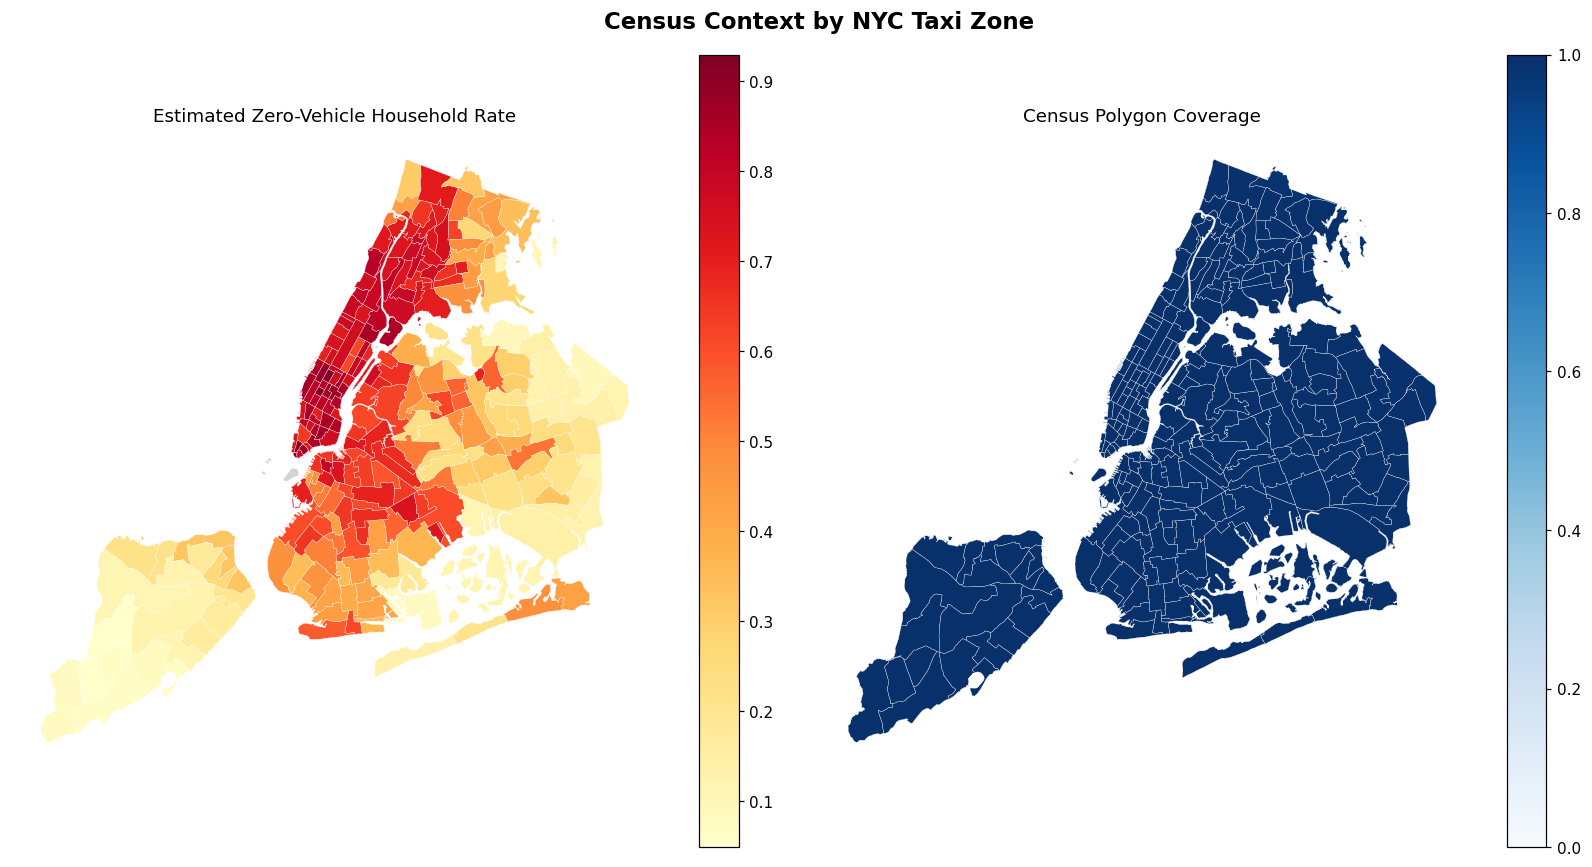

In [18]:
# Visual check of the main rate and spatial coverage
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
final_gdf.plot(
    column="zero_vehicle_household_rate", cmap="YlOrRd", linewidth=0.2,
    edgecolor="white", legend=True,
    missing_kwds={"color": "lightgrey", "label": "Unavailable"},
    ax=axes[0],
)
axes[0].set_title("Estimated Zero-Vehicle Household Rate")

final_gdf.plot(
    column="census_coverage_ratio", cmap="Blues", vmin=0, vmax=1,
    linewidth=0.2, edgecolor="white", legend=True, ax=axes[1],
)
axes[1].set_title("Census Polygon Coverage")

for axis in axes:
    axis.set_axis_off()
fig.suptitle("Census Context by NYC Taxi Zone", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


**Interpretation.** The first map shows the estimated zero-vehicle household rate. The second checks how completely Census polygons cover each taxi-zone polygon; low coverage should be treated cautiously.

### 8.3 Save the Integration-Ready Taxi-Zone Outputs


In [19]:
# Save only the two datasets required for later integration and modelling
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Non-spatial table for data integration and model training
final_table = pd.DataFrame(final_gdf.drop(columns="geometry"))
final_table.to_csv(CSV_PATH, index=False)

# Spatial version for mapping and spatial validation
if GPKG_PATH.exists():
    GPKG_PATH.unlink()
final_gdf.to_file(
    GPKG_PATH,
    layer="nyc_taxi_zone_zero_vehicle",
    driver="GPKG",
)

display(pd.DataFrame({
    "output": ["Taxi-zone CSV", "Taxi-zone GeoPackage"],
    "purpose": ["Data integration and modelling", "Mapping and spatial checks"],
    "path": [str(CSV_PATH), str(GPKG_PATH)],
    "rows": [len(final_table), len(final_gdf)],
    "saved": [CSV_PATH.exists(), GPKG_PATH.exists()],
}))


,output,purpose,path,rows,saved
0,Taxi-zone CSV,Data integration and modelling,C:\Asia Pacific University\All Module Notes\Se...,262,True
1,Taxi-zone GeoPackage,Mapping and spatial checks,C:\Asia Pacific University\All Module Notes\Se...,262,True


**Interpretation.** Both files contain the same 262 taxi-zone records after the validated water-only tracts have been excluded from the allocation step. Use the CSV for later data integration and model training. Use the GeoPackage only when geometry is needed for maps or spatial checks.


## Outcome

The pipeline produces the two files needed for the next stages: a CSV for data integration and modelling, and a GeoPackage for mapping and spatial validation. Each contains one record for every one of the 262 five-borough NYC taxi zones.

Water-only tracts are identified, displayed, justified, and excluded before the spatial allocation. Because the excluded tracts contain zero households, their removal does not change the estimated household totals. No additional tract-level output files are created.

### Reliability-threshold references

- Folch, D. C., Arribas-Bel, D., Koschinsky, J., & Spielman, S. E. (2016). Spatial variation in the quality of American Community Survey estimates. *Demography, 53*(5), 1535–1554. https://doi.org/10.1007/s13524-016-0499-1
- Spielman, S. E., Folch, D. C., & Nagle, N. N. (2014). Patterns and causes of uncertainty in the American Community Survey. *Applied Geography, 46*, 147–157. https://doi.org/10.1016/j.apgeog.2013.11.002
- U.S. Census Bureau. (2020). *Understanding and using American Community Survey data: What users of data for rural areas need to know*.
- U.S. Department of Agriculture, Economic Research Service. (2023). *The Poverty Area Measures data product* (Technical Bulletin No. 1967).
